In [1]:
import pandas as pd
import numpy as np
import glob
import os

In [2]:
# load the stop times dataframe and create a column to represent the month and year eacn stop times file was valid for
time_schedule_df = pd.read_csv("../../Datasets/monthly_stop_times.csv")
time_schedule_df['stops_month'] = (
    pd.to_datetime(time_schedule_df['stops_month'])
    .dt.to_period('M')
    .astype(str)
)

/var/folders/z7/152736054bv0sl_wm9ygspfr0000gn/T/ipykernel_2696/2748208043.py:2: DtypeWarning: Columns (0: trip_id, 1: stop_id) have mixed types. Specify dtype option on import or set low_memory=False.
  time_schedule_df = pd.read_csv("../../Datasets/monthly_stop_times.csv")


In [3]:
# GETTING ALL EVENTS DF 
df_list = []
for i in range(1, 6):
    dir = glob.glob(f'/Users/sierrawelsch/CS4100_Final/Datasets/202{i}/*.csv')
    for month_csv_file in dir:
        month_csv_file_df = pd.read_csv(month_csv_file)
        
        df_list.append(month_csv_file_df)
print(len(df_list))
final_events_df = pd.concat(df_list, ignore_index=True)

/var/folders/z7/152736054bv0sl_wm9ygspfr0000gn/T/ipykernel_2696/988666423.py:6: DtypeWarning: Columns (0: vehicle_label) have mixed types. Specify dtype option on import or set low_memory=False.
  month_csv_file_df = pd.read_csv(month_csv_file)


48


In [4]:
# building a mapping from stop id to stop name for the years where stop name is populated
stop_id_to_name = (
    final_events_df.dropna(subset=['stop_name'])
    .drop_duplicates(subset=['stop_id'])
    .set_index('stop_id')['stop_name']
)
stop_id_to_name

stop_id
70038              Bowdoin
70040    Government Center
70042                State
70044             Aquarium
70046             Maverick
               ...        
70099            Wollaston
70101        Quincy Center
70103         Quincy Adams
70105            Braintree
70511        Medford/Tufts
Name: stop_name, Length: 115, dtype: str

In [5]:
# fill missing stop_name values for events from 2022-2023 using the mapping 
final_events_df["stop_id"] = final_events_df["stop_id"].astype(str)
final_events_df['stop_name'] = final_events_df['stop_name'].fillna(
    final_events_df['stop_id'].map(stop_id_to_name)
)

In [6]:
import gc

# Step 1: drop columns and nulls on the original df inplace to shrink it immediately
final_events_df.drop(
    columns=["vehicle_id", "vehicle_label", "direction_id",
             "parent_station", "trunk_route_id", "direction"],
    inplace=True
)
final_events_df.dropna(subset=["service_date", "trip_id", "stop_id"], inplace=True)
gc.collect()

# Step 2: fill stop_sequence inplace, then drop sync_stop_sequence
final_events_df['stop_sequence'].fillna(final_events_df['sync_stop_sequence'], inplace=True)
final_events_df.drop(columns=['sync_stop_sequence'], inplace=True)
gc.collect()

# Step 3: type conversions inplace
final_events_df['service_date'] = pd.to_datetime(final_events_df['service_date'])
final_events_df['service_month'] = final_events_df['service_date'].dt.to_period('M').astype(str)
final_events_df['trip_id'] = final_events_df['trip_id'].astype(str)
final_events_df['stop_id'] = final_events_df['stop_id'].astype(str)
gc.collect()

# Step 4: rename instead of copying
new_final_events_df = final_events_df
del final_events_df
gc.collect()

# Step 5: time_schedule_df conversions
time_schedule_df['trip_id'] = time_schedule_df['trip_id'].astype(str)
time_schedule_df['stop_id'] = time_schedule_df['stop_id'].astype(str)

/var/folders/z7/152736054bv0sl_wm9ygspfr0000gn/T/ipykernel_2696/2067882567.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  final_events_df['stop_sequence'].fillna(final_events_df['sync_stop_sequence'], inplace=True)


In [7]:
# merge event data and expected departure/arrival time data for each trip_id, stop_id, stop_sequence pair for a specific month
merged_df = pd.merge(
    new_final_events_df,
    time_schedule_df,
    left_on=["trip_id", "stop_id", "stop_sequence", "service_month"],
    right_on=["trip_id", "stop_id", "stop_sequence", "stops_month"],
    how="inner"
)
merged_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,stop_name,service_month,arrival_time,departure_time,stops_month
0,2022-07-01,Red,52370898,70061,1.0,ARR,1656736332,88332.0,Alewife,2022-07,24:30:00,24:30:00,2022-07
1,2022-07-01,Red,52370898,70061,1.0,DEP,1656736536,88536.0,Alewife,2022-07,24:30:00,24:30:00,2022-07
2,2022-07-01,Red,52370899,70061,1.0,ARR,1656732080,84080.0,Alewife,2022-07,23:21:00,23:21:00,2022-07
3,2022-07-01,Red,52370899,70061,1.0,DEP,1656732768,84768.0,Alewife,2022-07,23:21:00,23:21:00,2022-07
4,2022-07-01,Red,52370900,70061,1.0,ARR,1656720398,72398.0,Alewife,2022-07,20:12:00,20:12:00,2022-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724116,2023-08-27,Red,58336963,70061,1.0,DEP,1693196975,88175.0,Alewife,2023-08,24:06:00,24:06:00,2023-08
5724117,2023-08-27,Red,58336963,70061,1.0,ARR,1693196198,87398.0,Alewife,2023-08,24:06:00,24:06:00,2023-08
5724118,2023-08-27,Red,58336966,70061,1.0,ARR,1693194953,86153.0,Alewife,2023-08,23:54:00,23:54:00,2023-08
5724119,2023-08-27,Red,58336968,70061,1.0,DEP,1693186329,77529.0,Alewife,2023-08,21:18:00,21:18:00,2023-08


In [8]:
merged_df['departure_time_sec'] = pd.to_timedelta(merged_df['departure_time']).dt.total_seconds()
merged_df['arrival_time_sec'] = pd.to_timedelta(merged_df['arrival_time']).dt.total_seconds()
merged_df[['departure_time_sec', 'arrival_time_sec']]

,departure_time_sec,arrival_time_sec
0,88200.0,88200.0
1,88200.0,88200.0
2,84060.0,84060.0
3,84060.0,84060.0
4,72720.0,72720.0
...,...,...
5724116,86760.0,86760.0
5724117,86760.0,86760.0
5724118,86040.0,86040.0
5724119,76680.0,76680.0


In [9]:
# one-hot encoding of route-id
route_encoding = pd.get_dummies(merged_df["route_id"], prefix="route_id", dtype=int)

merged_df = pd.concat([merged_df, route_encoding], axis=1)

In [14]:
# add delay column
merged_df['delay_sec'] = np.where(
    merged_df['event_type'] == 'ARR',
    merged_df['event_time_sec'] - merged_df['arrival_time_sec'],
    merged_df['event_time_sec'] - merged_df['departure_time_sec']
)

# Convert to minutes to make it more human readable
merged_df['delay_min'] = merged_df['delay_sec'] / 60

# adding an hour and a day column to try and identify delay patterns on the days of the week or hour of the day
merged_df['hour'] = merged_df['arrival_time_sec'] // 3600
merged_df['day_of_week'] = pd.to_datetime(merged_df['service_date']).dt.day_name()

merged_df.to_csv("../../Datasets/final_data.csv")



In [10]:
# look at time buckets (every 5 min) for grouping events and looking at the delays for a specific stop_id and arrival/departure time across multiple days
merged_df['time_bucket'] = (merged_df['arrival_time_sec'] // 300) * 300
arrival_merged_df= merged_df[merged_df['event_type'] == 'ARR']
arrival_merged_df


,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,stop_name,service_month,arrival_time,departure_time,stops_month,departure_time_sec,arrival_time_sec,delay_sec,delay_min,hour,day_of_week,time_bucket
0,2022-07-01,Red,52370898,70061,1.0,ARR,1656736332,88332.0,Alewife,2022-07,24:30:00,24:30:00,2022-07,88200.0,88200.0,132.0,2.200000,24.0,Friday,88200.0
2,2022-07-01,Red,52370899,70061,1.0,ARR,1656732080,84080.0,Alewife,2022-07,23:21:00,23:21:00,2022-07,84060.0,84060.0,20.0,0.333333,23.0,Friday,84000.0
4,2022-07-01,Red,52370900,70061,1.0,ARR,1656720398,72398.0,Alewife,2022-07,20:12:00,20:12:00,2022-07,72720.0,72720.0,-322.0,-5.366667,20.0,Friday,72600.0
7,2022-07-01,Red,52370901,70061,1.0,ARR,1656706612,58612.0,Alewife,2022-07,16:24:00,16:24:00,2022-07,59040.0,59040.0,-428.0,-7.133333,16.0,Friday,58800.0
8,2022-07-01,Red,52370902,70061,1.0,ARR,1656684176,36176.0,Alewife,2022-07,10:10:00,10:10:00,2022-07,36600.0,36600.0,-424.0,-7.066667,10.0,Friday,36600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724112,2023-08-27,Red,58336958,70061,1.0,ARR,1693145458,36658.0,Alewife,2023-08,10:19:00,10:19:00,2023-08,37140.0,37140.0,-482.0,-8.033333,10.0,Sunday,36900.0
5724115,2023-08-27,Red,58336961,70061,1.0,ARR,1693177592,68792.0,Alewife,2023-08,19:07:00,19:07:00,2023-08,68820.0,68820.0,-28.0,-0.466667,19.0,Sunday,68700.0
5724117,2023-08-27,Red,58336963,70061,1.0,ARR,1693196198,87398.0,Alewife,2023-08,24:06:00,24:06:00,2023-08,86760.0,86760.0,638.0,10.633333,24.0,Sunday,86700.0
5724118,2023-08-27,Red,58336966,70061,1.0,ARR,1693194953,86153.0,Alewife,2023-08,23:54:00,23:54:00,2023-08,86040.0,86040.0,113.0,1.883333,23.0,Sunday,85800.0


In [11]:
stop_df = arrival_merged_df[arrival_merged_df['stop_id'] == '70055'] # example stop id

stop_df = stop_df.reset_index()

# averaging the delay values for each day of the week across the hours to see if there are any delay trends on specific days of the week
arr_pivot = stop_df.pivot_table(
    index='hour',
    columns='day_of_week',
    values='delay_min',
    aggfunc='mean'   
)

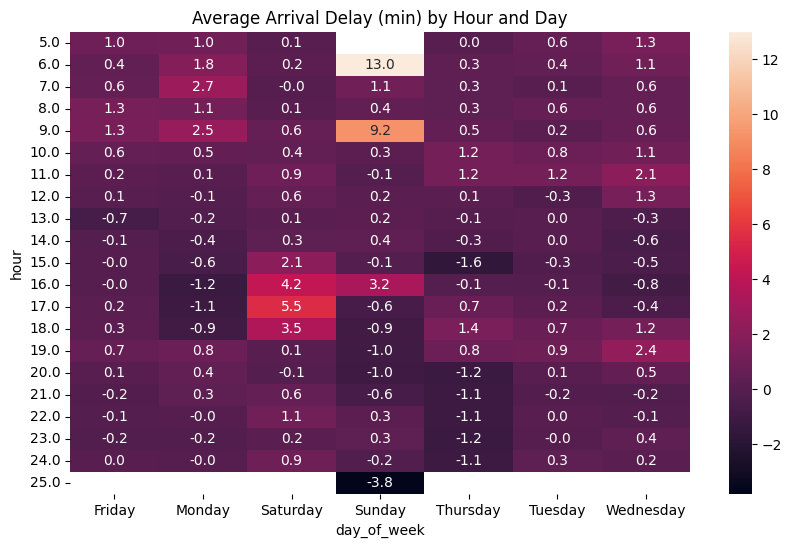

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(arr_pivot, annot=True, fmt=".1f")
plt.title("Average Arrival Delay (min) by Hour and Day")
plt.show()

In [13]:
# look at time buckets (every 5 min) for grouping events and looking at the delays for a specific stop_id and arrival/departure time across multiple days
merged_df['time_bucket'] = (merged_df['departure_time_sec'] // 300) * 300
departure_merged_df= merged_df[merged_df['event_type'] == 'DEP']
departure_merged_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,stop_name,service_month,arrival_time,departure_time,stops_month,departure_time_sec,arrival_time_sec,delay_sec,delay_min,hour,day_of_week,time_bucket
1,2022-07-01,Red,52370898,70061,1.0,DEP,1656736536,88536.0,Alewife,2022-07,24:30:00,24:30:00,2022-07,88200.0,88200.0,336.0,5.600000,24.0,Friday,88200.0
3,2022-07-01,Red,52370899,70061,1.0,DEP,1656732768,84768.0,Alewife,2022-07,23:21:00,23:21:00,2022-07,84060.0,84060.0,708.0,11.800000,23.0,Friday,84000.0
5,2022-07-01,Red,52370900,70061,1.0,DEP,1656720780,72780.0,Alewife,2022-07,20:12:00,20:12:00,2022-07,72720.0,72720.0,60.0,1.000000,20.0,Friday,72600.0
6,2022-07-01,Red,52370901,70061,1.0,DEP,1656707117,59117.0,Alewife,2022-07,16:24:00,16:24:00,2022-07,59040.0,59040.0,77.0,1.283333,16.0,Friday,58800.0
9,2022-07-01,Red,52370902,70061,1.0,DEP,1656684658,36658.0,Alewife,2022-07,10:10:00,10:10:00,2022-07,36600.0,36600.0,58.0,0.966667,10.0,Friday,36600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724110,2023-08-27,Red,58336956,70061,1.0,DEP,1693139996,31196.0,Alewife,2023-08,08:07:00,08:07:00,2023-08,29220.0,29220.0,1976.0,32.933333,8.0,Sunday,29100.0
5724113,2023-08-27,Red,58336958,70061,1.0,DEP,1693146044,37244.0,Alewife,2023-08,10:19:00,10:19:00,2023-08,37140.0,37140.0,104.0,1.733333,10.0,Sunday,36900.0
5724114,2023-08-27,Red,58336961,70061,1.0,DEP,1693178040,69240.0,Alewife,2023-08,19:07:00,19:07:00,2023-08,68820.0,68820.0,420.0,7.000000,19.0,Sunday,68700.0
5724116,2023-08-27,Red,58336963,70061,1.0,DEP,1693196975,88175.0,Alewife,2023-08,24:06:00,24:06:00,2023-08,86760.0,86760.0,1415.0,23.583333,24.0,Sunday,86700.0


In [14]:
# grouping to see if there are changes in time of day
departure_merged_df['hour'] = departure_merged_df['arrival_time_sec'] // 3600
departure_merged_df['day_of_week'] = pd.to_datetime(departure_merged_df['service_date']).dt.day_name()
departure_merged_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,stop_name,service_month,arrival_time,departure_time,stops_month,departure_time_sec,arrival_time_sec,delay_sec,delay_min,hour,day_of_week,time_bucket
1,2022-07-01,Red,52370898,70061,1.0,DEP,1656736536,88536.0,Alewife,2022-07,24:30:00,24:30:00,2022-07,88200.0,88200.0,336.0,5.600000,24.0,Friday,88200.0
3,2022-07-01,Red,52370899,70061,1.0,DEP,1656732768,84768.0,Alewife,2022-07,23:21:00,23:21:00,2022-07,84060.0,84060.0,708.0,11.800000,23.0,Friday,84000.0
5,2022-07-01,Red,52370900,70061,1.0,DEP,1656720780,72780.0,Alewife,2022-07,20:12:00,20:12:00,2022-07,72720.0,72720.0,60.0,1.000000,20.0,Friday,72600.0
6,2022-07-01,Red,52370901,70061,1.0,DEP,1656707117,59117.0,Alewife,2022-07,16:24:00,16:24:00,2022-07,59040.0,59040.0,77.0,1.283333,16.0,Friday,58800.0
9,2022-07-01,Red,52370902,70061,1.0,DEP,1656684658,36658.0,Alewife,2022-07,10:10:00,10:10:00,2022-07,36600.0,36600.0,58.0,0.966667,10.0,Friday,36600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724110,2023-08-27,Red,58336956,70061,1.0,DEP,1693139996,31196.0,Alewife,2023-08,08:07:00,08:07:00,2023-08,29220.0,29220.0,1976.0,32.933333,8.0,Sunday,29100.0
5724113,2023-08-27,Red,58336958,70061,1.0,DEP,1693146044,37244.0,Alewife,2023-08,10:19:00,10:19:00,2023-08,37140.0,37140.0,104.0,1.733333,10.0,Sunday,36900.0
5724114,2023-08-27,Red,58336961,70061,1.0,DEP,1693178040,69240.0,Alewife,2023-08,19:07:00,19:07:00,2023-08,68820.0,68820.0,420.0,7.000000,19.0,Sunday,68700.0
5724116,2023-08-27,Red,58336963,70061,1.0,DEP,1693196975,88175.0,Alewife,2023-08,24:06:00,24:06:00,2023-08,86760.0,86760.0,1415.0,23.583333,24.0,Sunday,86700.0


In [15]:
stop_df = departure_merged_df[departure_merged_df['stop_id'] == '70053'] # example stop id

stop_df = stop_df.reset_index()

# averaging the delay values for each day of the week across the hours to see if there are any delay trends on specific days of the week
dep_pivot = stop_df.pivot_table(
    index='hour',
    columns='day_of_week',
    values='delay_min',
    aggfunc='mean'   
)

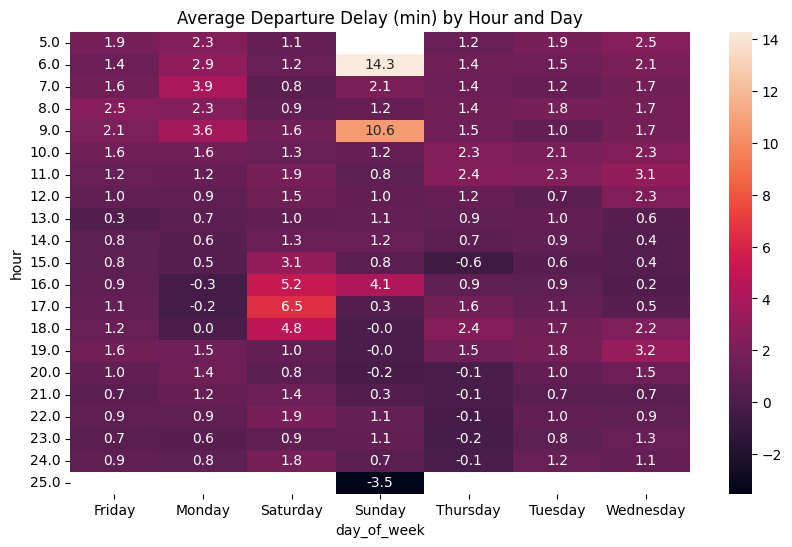

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(dep_pivot, annot=True, fmt=".1f")
plt.title("Average Departure Delay (min) by Hour and Day")
plt.show()

In [17]:
data = pd.read_csv("/Users/sierrawelsch/CS4100_Final/Datasets/final_data.csv")
data["day_of_week_num"] = data["day_of_week"].map(day_map)
data['month_num'] = data['service_date'].str[5:7].astype(int)

# combined the arrival and departure delay into one row per trip id and stop id
combined_data = data.pivot_table(
    index=["trip_id", "stop_sequence"],
    columns="event_type",
    values="delay_sec"
).reset_index()

# add a column for computing the arrival and departure delay at the previous stop per entry (delays usually have a domino effect)
combined_data["PRA"] = combined_data.groupby("trip_id")["ARR"].shift(1)
combined_data["PRD"] = combined_data.groupby("trip_id")["DEP"].shift(1)

# add a column for computing the arrival and departure delay at the previous 2 stops per entry
combined_data["PRA_2"] = combined_data.groupby("trip_id")["ARR"].shift(2)
combined_data["PRD_2"] = combined_data.groupby("trip_id")["DEP"].shift(2)

# get the other columns not present in the pivot table
other_cols = data.drop_duplicates(subset=["trip_id", "stop_sequence"])

# merge those columns back into the df
final_data = combined_data.merge(
    other_cols,
    on=["trip_id", "stop_sequence"],
    how="left"
)

# add a column that contains a binary value (0 or 1) if there is a delay at the current stop, the prev stop, or the prev 2 stops for classification purposes
final_data["delayed"] = ((final_data["ARR"] > 60) | (final_data["DEP"] > 60)).astype(int)
print(final_data["delayed"].value_counts())
# final_data["prev_delayed"] = ((final_data["PRA"] > 60) | (final_data["PRD"] > 60)).astype(int)
# final_data["prev_delayed_2"] = ((final_data["PRA_2"] > 60) | (final_data["PRD_2"] > 60)).astype(int)

final_data = final_data.fillna(0)
final_data = final_data.sort_values(["trip_id", "stop_sequence"])

data

FileNotFoundError: [Errno 2] No such file or directory: '/Users/sierrawelsch/CS4100_Final/Datasets/final_data.csv'